In [1]:
import numpy as np
import matplotlib.pyplot as plt
from gym_pybullet_drones.envs.BaseAviary import DroneModel
from stable_baselines3.common.monitor import Monitor

In [2]:
drone_model = DroneModel.CF2X
ep_len = 2

In [3]:
from TestAv3 import TestAv3

env = Monitor(TestAv3(drone_model=drone_model, ep_len=ep_len, freq=240))

[INFO] BaseAviary.__init__() loaded parameters from the drone's .urdf:
[INFO] m 0.027000, L 0.039700,
[INFO] ixx 0.000014, iyy 0.000014, izz 0.000022,
[INFO] kf 0.000000, km 0.000000,
[INFO] t2w 2.250000, max_speed_kmh 30.000000,
[INFO] gnd_eff_coeff 11.368590, prop_radius 0.023135,
[INFO] drag_xy_coeff 0.000001, drag_z_coeff 0.000001,
[INFO] dw_coeff_1 2267.180000, dw_coeff_2 0.160000, dw_coeff_3 -0.110000


c:\Users\awals\AppData\Local\Programs\Python\Python39\lib\site-packages\gym\logger.py:34: UserWarning: WARN: Box bound precision lowered by casting to float32
  warnings.warn(colorize("%s: %s" % ("WARN", msg % args), "yellow"))


In [4]:
from stable_baselines3 import PPO

model = PPO.load("attitude_sb3_logs/Av3PPO1/model", env=env)

In [5]:
cumm_reward = 0
curr_rpys = []
target_rpys = []
obs = env.reset()
actions = []
for i in range(ep_len*env.SIM_FREQ):
    # computing next action
    action, _ = model.predict(obs)
    actions.append(action)
    
    # stepping the environment
    obs, reward, done, info = env.step(action)
    target_rpys.append(info['target_rpy'])
    curr_rpys.append(info['curr_rpy'])

    # accumulating reward over episode
    cumm_reward += reward

print(cumm_reward)

-2.4009784756580497


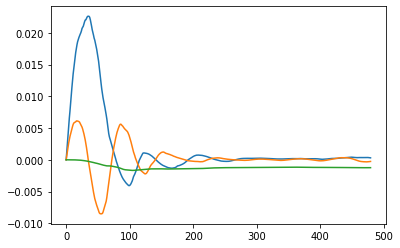

In [6]:
rpy_errs = np.array(target_rpys)-np.array(curr_rpys)
plt.plot(rpy_errs)
plt.show()

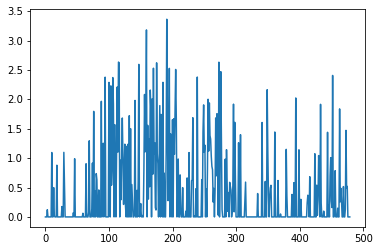

In [7]:
plt.plot(np.array(actions)[:,8])